In [106]:
here::i_am("snakemake/01_create_arrow.R")
library(BSgenome.Ocuniculus.NCBI.oryCun2)

# I/O
source(here::here("settings.R"))
io$output.directory <- file.path(io$basedir,"ArchR_test")
dir.create(file.path(io$output.directory), showWarnings = FALSE)
setwd(io$output.directory)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final

Setting default number of Parallel threads to 1.



In [107]:
# ArchR options
addArchRThreads(threads = 12)

Setting default number of Parallel threads to 12.



In [108]:
geneAnnotation = readRDS(file.path(io$basedir, 'geneAnnotation_new.rds'))

In [109]:
genomeAnnotation = createGenomeAnnotation(
  genome = BSgenome.Ocuniculus.NCBI.oryCun2,
  chromSizes = NULL,
  blacklist = NULL,
  filter = FALSE,
  filterChr = c("chrM")
)


Getting genome..

Getting chromSizes..

Getting blacklist..

Blacklist not downloaded! Continuing without, be careful for downstream biases..



In [110]:
chrs_genes = as.vector(seqnames(geneAnnotation$genes))
chrs_genome = as.vector(seqnames(genomeAnnotation$chromSizes))
intersect = intersect(chrs_genes, chrs_genome)
# test if we can subset
genomeAnnotation$chromSizes = genomeAnnotation$chromSizes[1:30]

# if it works actually subset to only chrs with genes
#genomeAnnotation$chromSizes = genomeAnnotation$chromSizes[genomeAnnotation$chromSizes@seqnames@values %in% intersect]

In [111]:
geneAnnotation$genes = geneAnnotation$genes[as.vector(seqnames(geneAnnotation$genes)) %in% genomeAnnotation$chromSizes@seqnames@values]
geneAnnotation$exons = geneAnnotation$exons[as.vector(seqnames(geneAnnotation$exons)) %in% genomeAnnotation$chromSizes@seqnames@values]
geneAnnotation$TSS = geneAnnotation$TSS[as.vector(seqnames(geneAnnotation$TSS)) %in% genomeAnnotation$chromSizes@seqnames@values]

In [114]:
geneAnnotation$genes

GRanges object with 21780 ranges and 2 metadata columns:
           seqnames          ranges strand |            gene_id
              <Rle>       <IRanges>  <Rle> |        <character>
      [1]      chr1     15188-30379      + | ENSOCUG00000014251
      [2]      chr1     52453-53038      + | ENSOCUG00000005054
      [3]      chr1     57421-74906      - | ENSOCUG00000005046
      [4]      chr1     75200-85749      + | ENSOCUG00000005044
      [5]      chr1     92423-95846      - | ENSOCUG00000005040
      ...       ...             ...    ... .                ...
  [21776] chrUn0008 5475029-5509535      - | ENSOCUG00000013420
  [21777] chrUn0008 5526270-5544741      - | ENSOCUG00000024159
  [21778] chrUn0008 5554610-5569952      - | ENSOCUG00000013413
  [21779] chrUn0008 5603833-5682641      + | ENSOCUG00000038015
  [21780] chrUn0008 5698008-5699199      + | ENSOCUG00000030550
                   gene_name
                 <character>
      [1]              WDR31
      [2]             RN

In [112]:
args = list()
args$sample = 'BGRGP1'
args$min_fragments = 8000
args$min_tss_score = 2.8
args$outdir = io$output.directory

In [113]:
fragment_file_path = paste0(io$basedir, '/data/', args$sample, '_fragments.tsv.gz')

In [10]:
#Create Arrow File
ArrowFiles <- createArrowFiles(
  inputFiles = fragment_file_path,
  sampleNames = paste0('rabbit_', args$sample),
    
  minTSS = args$min_tss_score, #Dont set this too high because you can always increase later
  minFrags = args$min_fragments , 
    
  addTileMat = FALSE,
  addGeneScoreMat = FALSE,
    
  geneAnnotation = geneAnnotation,
  genomeAnnotation = genomeAnnotation, 
    force=TRUE
)

Found Gene Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,chrUn0282,chrUn0346,chrUn0403,chrUn0438,chrUn0467,chrUn0497,chrUn0525,chrUn0543,chrUn0551,chrUn0557,chrUn0567,chrUn0572,chrUn0583,chrUn0586,chrUn0593,chrUn0618,chrUn0631,chrUn0632,chrUn0646,chrUn0647,chrUn0652,chrUn0657,chrUn0700,chrUn0725,chrUn0736,chrUn0740,chrUn0744,chrUn0750,chrUn0763,chrUn0772,chrUn0776,chrUn0778,chrUn0795,chrUn0817,chrUn0820,chrUn0836,chrUn0842,chrUn0864,chrUn0888,chrUn0897,chrUn0899,chrUn0909,chrUn0918,chrUn0927,chrUn0928,chrUn0961,chrUn0963,chrUn0969,chrUn0971,chrUn0976,chrUn0987,chrUn1014,chrUn1016,chrUn1021,chrUn1028,chrUn1029,chrUn1030,chrUn1031,chrUn1032,chrUn1033,chrUn1034,chrUn1035,chrUn1038,chrUn1052,chrUn1058,chrUn1062,chrUn1066,chrUn1070,chrUn1073,chrUn1091,chrUn1093,chrUn1094,chrUn1101,chrUn1104,chrUn1105,chrUn1106,chrUn1111,chrUn1114,chrUn1127,chrUn1130,chrUn1131,chrUn1133,chrUn1134,chrUn1141,chrUn1143,chrUn1163,chrUn1164,chrUn1168,chrUn1176,chrUn1180,chrUn1197,chrUn1203,chrUn120

Found Exon Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,chrUn0282,chrUn0346,chrUn0403,chrUn0438,chrUn0467,chrUn0497,chrUn0525,chrUn0543,chrUn0551,chrUn0557,chrUn0567,chrUn0572,chrUn0583,chrUn0586,chrUn0593,chrUn0618,chrUn0631,chrUn0632,chrUn0646,chrUn0647,chrUn0652,chrUn0657,chrUn0700,chrUn0725,chrUn0736,chrUn0740,chrUn0744,chrUn0750,chrUn0763,chrUn0772,chrUn0776,chrUn0778,chrUn0795,chrUn0817,chrUn0820,chrUn0836,chrUn0842,chrUn0864,chrUn0888,chrUn0897,chrUn0899,chrUn0909,chrUn0918,chrUn0927,chrUn0928,chrUn0961,chrUn0963,chrUn0969,chrUn0971,chrUn0976,chrUn0987,chrUn1014,chrUn1016,chrUn1021,chrUn1028,chrUn1029,chrUn1030,chrUn1031,chrUn1032,chrUn1033,chrUn1034,chrUn1035,chrUn1038,chrUn1052,chrUn1058,chrUn1062,chrUn1066,chrUn1070,chrUn1073,chrUn1091,chrUn1093,chrUn1094,chrUn1101,chrUn1104,chrUn1105,chrUn1106,chrUn1111,chrUn1114,chrUn1127,chrUn1130,chrUn1131,chrUn1133,chrUn1134,chrUn1141,chrUn1143,chrUn1163,chrUn1164,chrUn1168,chrUn1176,chrUn1180,chrUn1197,chrUn1203,chrUn120

Found TSS Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,chrUn0282,chrUn0346,chrUn0403,chrUn0438,chrUn0467,chrUn0497,chrUn0525,chrUn0543,chrUn0551,chrUn0557,chrUn0567,chrUn0572,chrUn0583,chrUn0586,chrUn0593,chrUn0618,chrUn0631,chrUn0632,chrUn0646,chrUn0647,chrUn0652,chrUn0657,chrUn0700,chrUn0725,chrUn0736,chrUn0740,chrUn0744,chrUn0750,chrUn0763,chrUn0772,chrUn0776,chrUn0778,chrUn0795,chrUn0817,chrUn0820,chrUn0836,chrUn0842,chrUn0864,chrUn0888,chrUn0897,chrUn0899,chrUn0909,chrUn0918,chrUn0927,chrUn0928,chrUn0961,chrUn0963,chrUn0969,chrUn0971,chrUn0976,chrUn0987,chrUn1014,chrUn1016,chrUn1021,chrUn1028,chrUn1029,chrUn1030,chrUn1031,chrUn1032,chrUn1033,chrUn1034,chrUn1035,chrUn1038,chrUn1052,chrUn1058,chrUn1062,chrUn1066,chrUn1070,chrUn1073,chrUn1091,chrUn1093,chrUn1094,chrUn1101,chrUn1104,chrUn1105,chrUn1106,chrUn1111,chrUn1114,chrUn1127,chrUn1130,chrUn1131,chrUn1133,chrUn1134,chrUn1141,chrUn1143,chrUn1163,chrUn1164,chrUn1168,chrUn1176,chrUn1180,chrUn1197,chrUn1203,chrUn1209

ArchR logging to : ArchRLogs/ArchR-createArrows-3642f42f757d6-Date-2022-01-26_Time-16-27-50.log
If there is an issue, please report to github with logFile!

Cleaning Temporary Files

2022-01-26 16:27:50 : Batch Execution w/ safelapply!, 0 mins elapsed.

(rabbit_BGRGP5 : 1 of 1) Determining Arrow Method to use!

2022-01-26 16:27:50 : (rabbit_BGRGP5 : 1 of 1) Reading In Fragments from inputFiles (readMethod = tabix), 0.001 mins elapsed.

2022-01-26 16:27:50 : (rabbit_BGRGP5 : 1 of 1) Tabix Bed To Temporary File, 0.001 mins elapsed.

2022-01-26 16:32:21 : (rabbit_BGRGP5 : 1 of 1) Successful creation of Temporary File, 4.521 mins elapsed.

2022-01-26 16:32:21 : (rabbit_BGRGP5 : 1 of 1) Creating ArrowFile From Temporary File, 4.521 mins elapsed.

2022-01-26 16:34:37 : (rabbit_BGRGP5 : 1 of 1) Successful creation of Arrow File, 6.785 mins elapsed.

2022-01-26 16:36:07 : (rabbit_BGRGP5 : 1 of 1) CellStats : Number of Cells Pass Filter = 4627 , 8.293 mins elapsed.

2022-01-26 16:36:07 : (rabbi

In [96]:
ArrowFiles = file.path(io$output.directory, list.files(io$output.directory, pattern ='arrow'))

In [97]:
ArrowFiles

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/ArchR_test/rabbit_BGRGP5.arrow"

In [98]:
proj <- ArchRProject(
  ArrowFiles = ArrowFiles, 
  outputDirectory = "Project",
  copyArrows = TRUE, #This is recommened so that you maintain an unaltered copy for later usage.
  geneAnnotation = geneAnnotation,
  genomeAnnotation = genomeAnnotation
)

Found Gene Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,chrUn0282,chrUn0346,chrUn0403,chrUn0438,chrUn0467,chrUn0497,chrUn0525,chrUn0543,chrUn0551,chrUn0557,chrUn0567,chrUn0572,chrUn0583,chrUn0586,chrUn0593,chrUn0618,chrUn0631,chrUn0632,chrUn0646,chrUn0647,chrUn0652,chrUn0657,chrUn0700,chrUn0725,chrUn0736,chrUn0740,chrUn0744,chrUn0750,chrUn0763,chrUn0772,chrUn0776,chrUn0778,chrUn0795,chrUn0817,chrUn0820,chrUn0836,chrUn0842,chrUn0864,chrUn0888,chrUn0897,chrUn0899,chrUn0909,chrUn0918,chrUn0927,chrUn0928,chrUn0961,chrUn0963,chrUn0969,chrUn0971,chrUn0976,chrUn0987,chrUn1014,chrUn1016,chrUn1021,chrUn1028,chrUn1029,chrUn1030,chrUn1031,chrUn1032,chrUn1033,chrUn1034,chrUn1035,chrUn1038,chrUn1052,chrUn1058,chrUn1062,chrUn1066,chrUn1070,chrUn1073,chrUn1091,chrUn1093,chrUn1094,chrUn1101,chrUn1104,chrUn1105,chrUn1106,chrUn1111,chrUn1114,chrUn1127,chrUn1130,chrUn1131,chrUn1133,chrUn1134,chrUn1141,chrUn1143,chrUn1163,chrUn1164,chrUn1168,chrUn1176,chrUn1180,chrUn1197,chrUn1203,chrUn120

Found Exon Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,chrUn0282,chrUn0346,chrUn0403,chrUn0438,chrUn0467,chrUn0497,chrUn0525,chrUn0543,chrUn0551,chrUn0557,chrUn0567,chrUn0572,chrUn0583,chrUn0586,chrUn0593,chrUn0618,chrUn0631,chrUn0632,chrUn0646,chrUn0647,chrUn0652,chrUn0657,chrUn0700,chrUn0725,chrUn0736,chrUn0740,chrUn0744,chrUn0750,chrUn0763,chrUn0772,chrUn0776,chrUn0778,chrUn0795,chrUn0817,chrUn0820,chrUn0836,chrUn0842,chrUn0864,chrUn0888,chrUn0897,chrUn0899,chrUn0909,chrUn0918,chrUn0927,chrUn0928,chrUn0961,chrUn0963,chrUn0969,chrUn0971,chrUn0976,chrUn0987,chrUn1014,chrUn1016,chrUn1021,chrUn1028,chrUn1029,chrUn1030,chrUn1031,chrUn1032,chrUn1033,chrUn1034,chrUn1035,chrUn1038,chrUn1052,chrUn1058,chrUn1062,chrUn1066,chrUn1070,chrUn1073,chrUn1091,chrUn1093,chrUn1094,chrUn1101,chrUn1104,chrUn1105,chrUn1106,chrUn1111,chrUn1114,chrUn1127,chrUn1130,chrUn1131,chrUn1133,chrUn1134,chrUn1141,chrUn1143,chrUn1163,chrUn1164,chrUn1168,chrUn1176,chrUn1180,chrUn1197,chrUn1203,chrUn120

Found TSS Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,chrUn0282,chrUn0346,chrUn0403,chrUn0438,chrUn0467,chrUn0497,chrUn0525,chrUn0543,chrUn0551,chrUn0557,chrUn0567,chrUn0572,chrUn0583,chrUn0586,chrUn0593,chrUn0618,chrUn0631,chrUn0632,chrUn0646,chrUn0647,chrUn0652,chrUn0657,chrUn0700,chrUn0725,chrUn0736,chrUn0740,chrUn0744,chrUn0750,chrUn0763,chrUn0772,chrUn0776,chrUn0778,chrUn0795,chrUn0817,chrUn0820,chrUn0836,chrUn0842,chrUn0864,chrUn0888,chrUn0897,chrUn0899,chrUn0909,chrUn0918,chrUn0927,chrUn0928,chrUn0961,chrUn0963,chrUn0969,chrUn0971,chrUn0976,chrUn0987,chrUn1014,chrUn1016,chrUn1021,chrUn1028,chrUn1029,chrUn1030,chrUn1031,chrUn1032,chrUn1033,chrUn1034,chrUn1035,chrUn1038,chrUn1052,chrUn1058,chrUn1062,chrUn1066,chrUn1070,chrUn1073,chrUn1091,chrUn1093,chrUn1094,chrUn1101,chrUn1104,chrUn1105,chrUn1106,chrUn1111,chrUn1114,chrUn1127,chrUn1130,chrUn1131,chrUn1133,chrUn1134,chrUn1141,chrUn1143,chrUn1163,chrUn1164,chrUn1168,chrUn1176,chrUn1180,chrUn1197,chrUn1203,chrUn1209

Validating Arrows...

Getting SampleNames...

1 


Copying ArrowFiles to Ouptut Directory! If you want to save disk space set copyArrows = FALSE

1 


Getting Cell Metadata...

1 


Merging Cell Metadata...

Initializing ArchRProject...


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ ____

In [99]:
proj = proj[proj@cellColData$TSSEnrichment > 4 & proj@cellColData$nFrags > 20000]

In [100]:
proj


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/ArchR_test/Project 
samples(1): rabbit_BGRGP5
sampleColData names(1): ArrowFiles
cellColData names(11): Sample TSSEnrichment ... nFrags nDiFrags
numberOfCells(1): 878
medianTSS(1): 4.3055
medianFrags(1): 38055

In [101]:
proj = addCellColData(
  ArchRProj = proj,
  data = c(rep('test1', 300), rep('test2', nrow(proj@cellColData)-300)),
  name = 'test',
  cells = rownames(proj@cellColData),
  force = TRUE
)

In [102]:
# Add Group Coverages
proj <- addGroupCoverages(proj, 
  groupBy = 'test',
  useLabels = FALSE,
  force = TRUE
)

ArchR logging to : ArchRLogs/ArchR-addGroupCoverages-3330f7a842e8a-Date-2022-01-26_Time-15-39-27.log
If there is an issue, please report to github with logFile!

test1 (1 of 2) : CellGroups N = 2

test2 (2 of 2) : CellGroups N = 2

2022-01-26 15:39:30 : Creating Coverage Files!, 0.045 mins elapsed.

2022-01-26 15:39:30 : Batch Execution w/ safelapply!, 0.045 mins elapsed.

2022-01-26 15:41:26 : Adding Kmer Bias to Coverage Files!, 1.983 mins elapsed.

Completed Kmer Bias Calculation

Adding Kmer Bias (1 of 4)

Adding Kmer Bias (2 of 4)

Adding Kmer Bias (3 of 4)

Adding Kmer Bias (4 of 4)

2022-01-26 15:42:40 : Finished Creation of Coverage Files!, 3.212 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-addGroupCoverages-3330f7a842e8a-Date-2022-01-26_Time-15-39-27.log



In [103]:
proj <- addReproduciblePeakSet(
  ArchRProj = proj, 
  groupBy = 'test', 
  peakMethod = "Macs2",
 genomeSize = 2.7e9)

Searching For MACS2..

Found with $path!

ArchR logging to : ArchRLogs/ArchR-addReproduciblePeakSet-3330f208994da-Date-2022-01-26_Time-15-42-41.log
If there is an issue, please report to github with logFile!

Calling Peaks with Macs2

2022-01-26 15:42:42 : Peak Calling Parameters!, 0.015 mins elapsed.



      Group nCells nCellsUsed nReplicates nMin nMax maxPeaks
test1 test1    300         79           2   40   40    39500
test2 test2    578         80           2   40   40    40000


2022-01-26 15:42:42 : Batching Peak Calls!, 0.015 mins elapsed.

2022-01-26 15:42:42 : Batch Execution w/ safelapply!, 0 mins elapsed.

2022-01-26 15:43:55 : Identifying Reproducible Peaks!, 1.24 mins elapsed.

2022-01-26 15:44:14 : Creating Union Peak Set!, 1.561 mins elapsed.

Converged after 3 iterations!

Plotting Ggplot!

2022-01-26 15:44:37 : Finished Creating Union Peak Set (53677)!, 1.943 mins elapsed.



In [104]:
proj <- addPeakMatrix(proj)

ArchR logging to : ArchRLogs/ArchR-addPeakMatrix-3330f4fdd3548-Date-2022-01-26_Time-15-44-37.log
If there is an issue, please report to github with logFile!

2022-01-26 15:44:38 : Batch Execution w/ safelapply!, 0 mins elapsed.

2022-01-26 15:44:38 : Adding rabbit_BGRGP5 to PeakMatrix for Chr (1 of 99)!, 0.004 mins elapsed.

2022-01-26 15:44:45 : Adding rabbit_BGRGP5 to PeakMatrix for Chr (2 of 99)!, 0.116 mins elapsed.

2022-01-26 15:44:48 : Adding rabbit_BGRGP5 to PeakMatrix for Chr (3 of 99)!, 0.174 mins elapsed.

2022-01-26 15:44:52 : Adding rabbit_BGRGP5 to PeakMatrix for Chr (4 of 99)!, 0.232 mins elapsed.

2022-01-26 15:44:55 : Adding rabbit_BGRGP5 to PeakMatrix for Chr (5 of 99)!, 0.278 mins elapsed.

2022-01-26 15:44:57 : Adding rabbit_BGRGP5 to PeakMatrix for Chr (6 of 99)!, 0.317 mins elapsed.

2022-01-26 15:44:59 : Adding rabbit_BGRGP5 to PeakMatrix for Chr (7 of 99)!, 0.356 mins elapsed.

2022-01-26 15:45:04 : Adding rabbit_BGRGP5 to PeakMatrix for Chr (8 of 99)!, 0.426 mi

2022-01-26 15:47:45 : Adding rabbit_BGRGP5 to PeakMatrix for Chr (82 of 99)!, 3.112 mins elapsed.

2022-01-26 15:47:47 : Adding rabbit_BGRGP5 to PeakMatrix for Chr (83 of 99)!, 3.147 mins elapsed.

2022-01-26 15:47:49 : Adding rabbit_BGRGP5 to PeakMatrix for Chr (84 of 99)!, 3.181 mins elapsed.

2022-01-26 15:47:51 : Adding rabbit_BGRGP5 to PeakMatrix for Chr (85 of 99)!, 3.215 mins elapsed.

2022-01-26 15:47:53 : Adding rabbit_BGRGP5 to PeakMatrix for Chr (86 of 99)!, 3.249 mins elapsed.

2022-01-26 15:47:55 : Adding rabbit_BGRGP5 to PeakMatrix for Chr (87 of 99)!, 3.283 mins elapsed.

2022-01-26 15:47:57 : Adding rabbit_BGRGP5 to PeakMatrix for Chr (88 of 99)!, 3.317 mins elapsed.

2022-01-26 15:47:59 : Adding rabbit_BGRGP5 to PeakMatrix for Chr (89 of 99)!, 3.352 mins elapsed.

2022-01-26 15:48:01 : Adding rabbit_BGRGP5 to PeakMatrix for Chr (90 of 99)!, 3.386 mins elapsed.

2022-01-26 15:48:03 : Adding rabbit_BGRGP5 to PeakMatrix for Chr (91 of 99)!, 3.42 mins elapsed.

2022-01-26 

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-3330f14ff54c4-Date-2022-01-26_Time-15-48-22.log
If there is an issue, please report to github with logFile!

2022-01-26 15:48:23 : Computing Total Across All Features, 0.001 mins elapsed.

2022-01-26 15:48:24 : Computing Top Features, 0.03 mins elapsed.

###########
2022-01-26 15:48:26 : Running LSI (1 of 2) on Top Features, 0.049 mins elapsed.
###########

2022-01-26 15:48:26 : Creating Partial Matrix, 0.049 mins elapsed.

2022-01-26 15:48:32 : Computing LSI, 0.16 mins elapsed.

2022-01-26 15:48:39 : Identifying Clusters, 0.281 mins elapsed.

2022-01-26 15:48:41 : Identified 6 Clusters, 0.308 mins elapsed.

2022-01-26 15:48:41 : Saving LSI Iteration, 0.309 mins elapsed.

2022-01-26 15:48:50 : Creating Cluster Matrix on the total Group Features, 0.455 mins elapsed.

2022-01-26 15:49:15 : Computing Variable Features, 0.878 mins elapsed.

###########
2022-01-26 15:49:15 : Running LSI (2 of 2) on Variable Features, 0.8

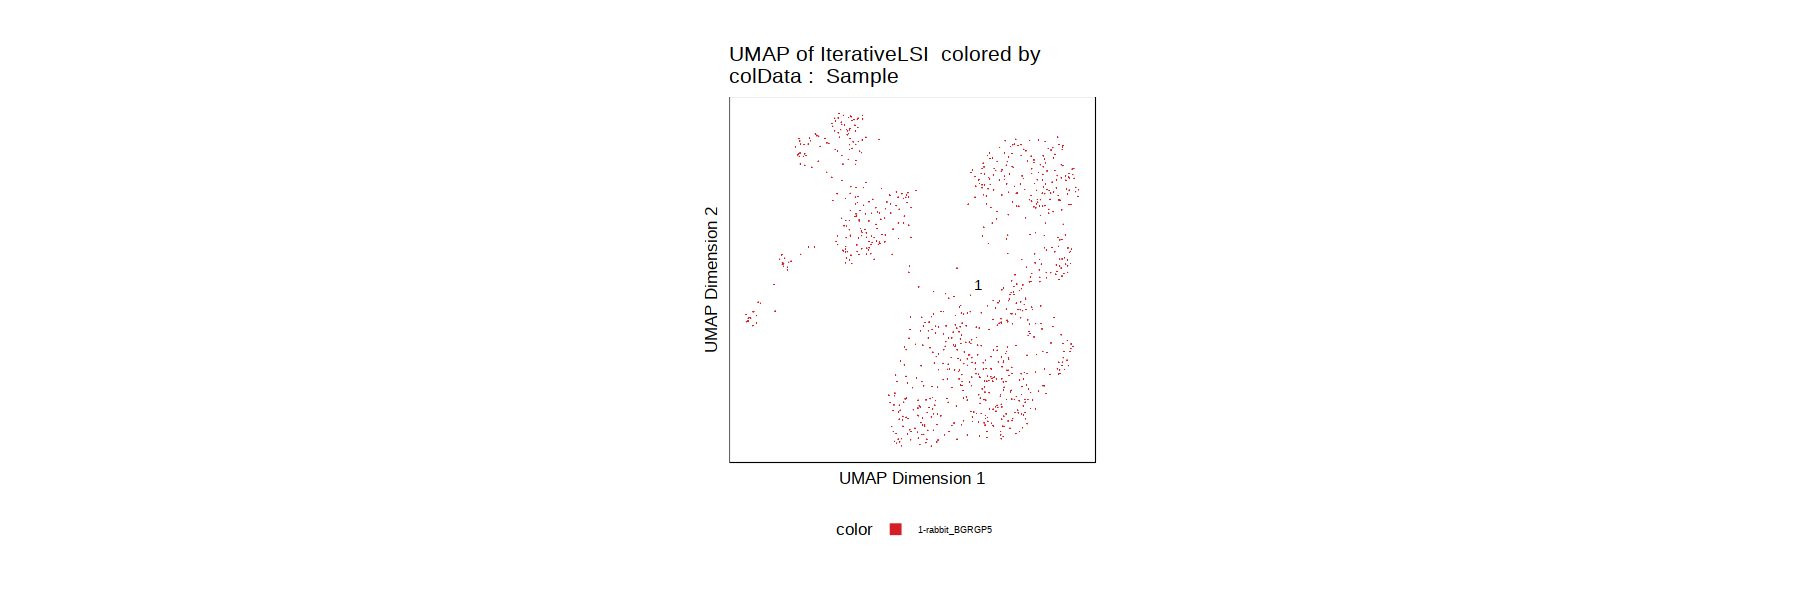

In [105]:
proj = addIterativeLSI(
          ArchRProj = proj,
          useMatrix = 'PeakMatrix')

proj <- addUMAP(
          ArchRProj = proj)
plotEmbedding(proj)

In [106]:
getAvailableMatrices(proj)

[1] "PeakMatrix"

In [107]:
# Motif enrichment
proj <- addMotifAnnotations(ArchRProj = proj, motifSet = "cisbp", name = "Motif", species='Homo sapiens', force=TRUE)

ArchR logging to : ArchRLogs/ArchR-addMotifAnnotations-3330f4d4fa1d3-Date-2022-01-26_Time-15-49-39.log
If there is an issue, please report to github with logFile!

2022-01-26 15:49:39 : Gettting Motif Set, Species : Homo sapiens, 0.004 mins elapsed.

Using version 2 motifs!

2022-01-26 15:49:43 : Finding Motif Positions with motifmatchr!, 0.064 mins elapsed.

2022-01-26 15:51:33 : Creating Motif Overlap Matrix, 1.9 mins elapsed.

2022-01-26 15:51:34 : Finished Getting Motif Info!, 1.914 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-addMotifAnnotations-3330f4d4fa1d3-Date-2022-01-26_Time-15-49-39.log



In [108]:
proj


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/ArchR_test/Project 
samples(1): rabbit_BGRGP5
sampleColData names(1): ArrowFiles
cellColData names(14): Sample TSSEnrichment ... ReadsInPeaks FRIP
numberOfCells(1): 878
medianTSS(1): 4.3055
medianFrags(1): 38055

In [109]:
proj <- addBgdPeaks(proj, method='ArchR', force=TRUE) 

Identifying Background Peaks!



In [110]:
proj <- addDeviationsMatrix(
  ArchRProj = proj, 
  peakAnnotation = "Motif",
  force = TRUE
)

Using Previous Background Peaks!

ArchR logging to : ArchRLogs/ArchR-addDeviationsMatrix-3330f4cfea0d9-Date-2022-01-26_Time-15-51-38.log
If there is an issue, please report to github with logFile!



NULL


2022-01-26 15:51:42 : Batch Execution w/ safelapply!, 0 mins elapsed.

2022-01-26 15:51:43 : chromVAR deviations rabbit_BGRGP5 (1 of 1) Schep (2017), 0.018 mins elapsed.

2022-01-26 15:52:00 : rabbit_BGRGP5 (1 of 1) : Deviations for Annotation 43 of 870, 0.165 mins elapsed.

2022-01-26 15:52:10 : rabbit_BGRGP5 (1 of 1) : Deviations for Annotation 86 of 870, 0.332 mins elapsed.

2022-01-26 15:52:20 : rabbit_BGRGP5 (1 of 1) : Deviations for Annotation 129 of 870, 0.49 mins elapsed.

2022-01-26 15:52:31 : rabbit_BGRGP5 (1 of 1) : Deviations for Annotation 172 of 870, 0.678 mins elapsed.

2022-01-26 15:52:44 : rabbit_BGRGP5 (1 of 1) : Deviations for Annotation 215 of 870, 0.898 mins elapsed.

2022-01-26 15:52:57 : rabbit_BGRGP5 (1 of 1) : Deviations for Annotation 258 of 870, 1.11 mins elapsed.

2022-01-26 15:53:09 : rabbit_BGRGP5 (1 of 1) : Deviations for Annotation 301 of 870, 1.303 mins elapsed.

2022-01-26 15:53:20 : rabbit_BGRGP5 (1 of 1) : Deviations for Annotation 344 of 870, 1.485 

In [111]:
plotVarDev <- getVarDeviations(proj, name = "MotifMatrix", plot = TRUE)

DataFrame with 6 rows and 6 columns
     seqnames     idx      name combinedVars combinedMeans      rank
        <Rle> <array>   <array>    <numeric>     <numeric> <integer>
f402        z     402  GSC2_402      6.45988    -0.0215258         1
f560        z     560 DMBX1_560      6.44390    -0.0336267         2
f470        z     470   GSC_470      6.34381    -0.0297203         3
f754        z     754  SOX4_754      6.12440    -0.0966855         4
f723        z     723  RFX3_723      5.94774    -0.0299848         5
f725        z     725  RFX4_725      5.84862    -0.0280151         6


Warning message:
“ggrepel: 8 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


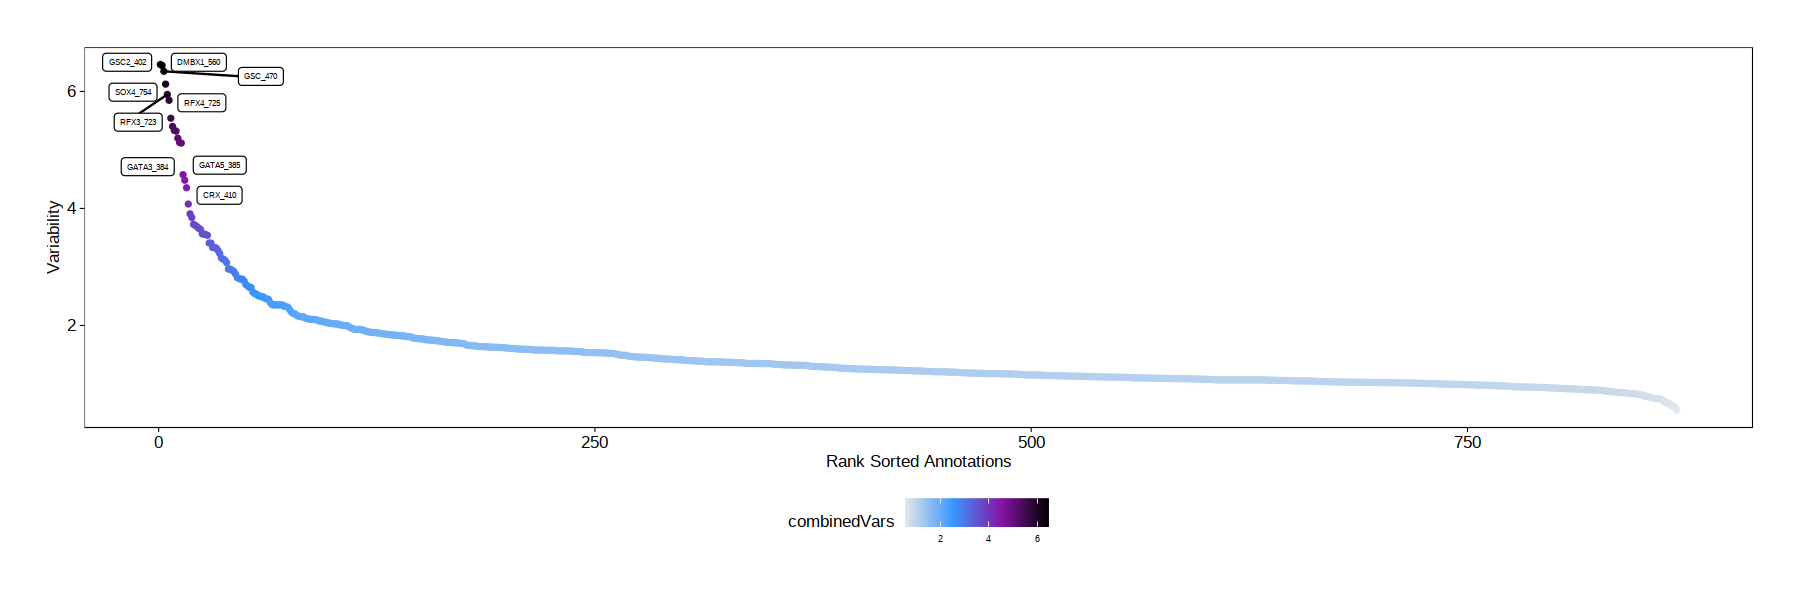

In [112]:
plotVarDev

In [113]:
getAvailableMatrices(proj)

[1] "MotifMatrix" "PeakMatrix"

Getting ImputeWeights

No imputeWeights found, returning NULL

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-3330f608f874-Date-2022-01-26_Time-15-57-06.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = MotifMatrix

Getting Matrix Values...

2022-01-26 15:57:08 : 

1 


Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-3330f608f874-Date-2022-01-26_Time-15-57-06.log



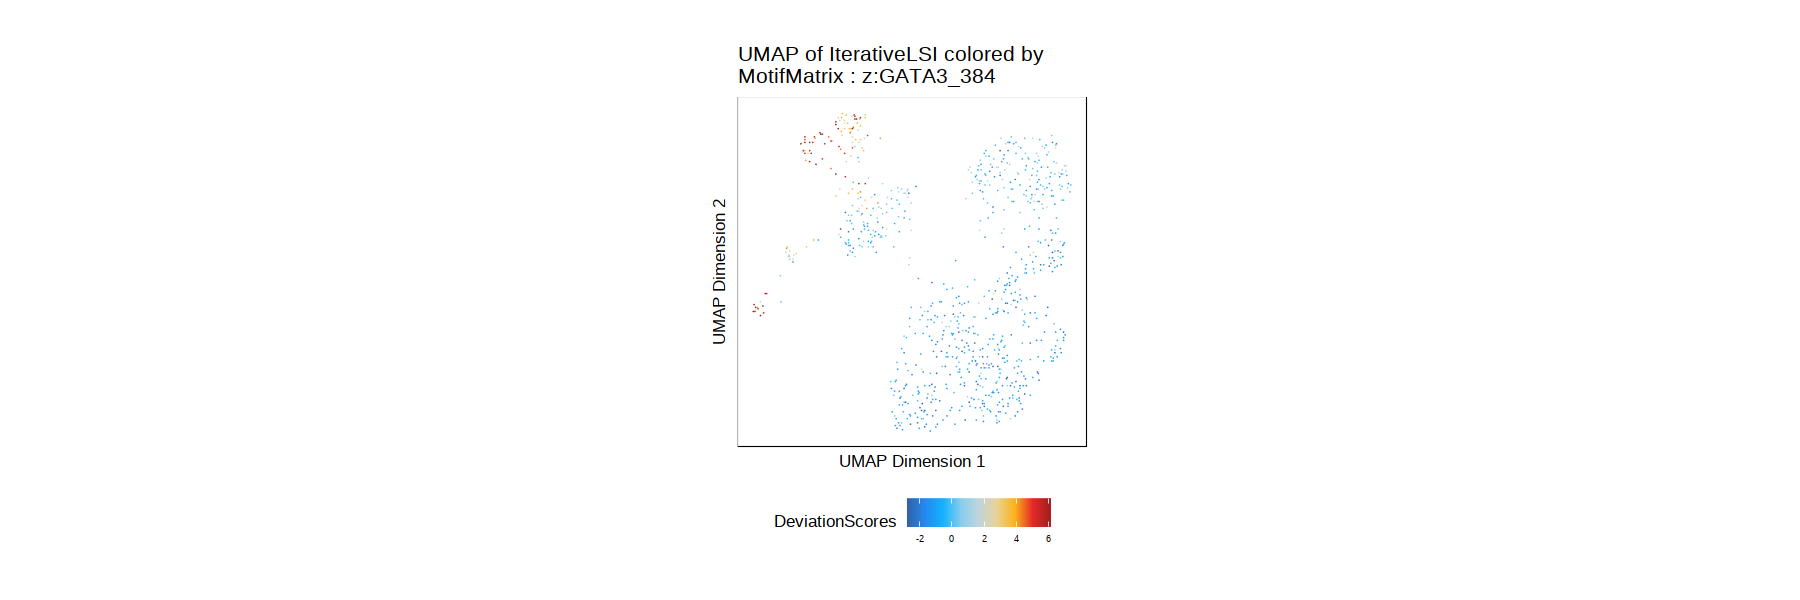

In [116]:
markerMotifs <- grep("z:", getFeatures(proj, select = 'GATA3', useMatrix = "MotifMatrix"), value = TRUE)
plotEmbedding(
        ArchRProj = proj, 
        colorBy = "MotifMatrix", 
        name = markerMotifs)